# Taller 04 — Problemas de Satisfacción de Restricciones: K-Means

**Curso:** Inteligencia Artificial — ELP 8012  
**Programa:** Ingeniería de Sistemas — Universidad del Norte  
**Profesor:** Eduardo Zurek, Ph.D.  
**Autores:** *Completar nombres del grupo*  
**Fecha:** 27 de agosto de 2026
**Integrante:** Andrea Quintero - Wilmer Santiago - Bryan Montoya

## Objetivo

Diseñar e implementar K-Means sobre un conjunto sintético bidimensional con **6 grupos gaussianos isotrópicos**, igual número de puntos por grupo, diferentes desviaciones estándar, dos grupos parcialmente superpuestos y outliers uniformes. Posteriormente se remueven los outliers, se exploran valores de **K = 2,...,12** y se selecciona K mediante **Silhouette, Elbow y Ground Truth (ARI/NMI)**.

El algoritmo de K-Means no utiliza las etiquetas verdaderas durante el agrupamiento. Las etiquetas se conservan únicamente para la evaluación basada en Ground Truth.


## 1. Importación de librerías y configuración

Se fija una semilla para que los resultados sean reproducibles.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)


## 2. Generación de los datos sintéticos

Se generan 6 grupos con 200 puntos cada uno. Cada grupo se obtiene mediante una distribución normal bidimensional con la misma desviación estándar en ambos ejes. Por tanto, la matriz de covarianza es `sigma² I`, lo que corresponde a una distribución gaussiana isotrópica.

Las diferentes desviaciones estándar producen diferentes densidades aparentes. Los grupos 5 y 6 tienen centros próximos para producir superposición parcial. Además, se agregan 150 outliers mediante una distribución uniforme en `[-10,10] × [-10,10]`.


In [2]:
centers = np.array([
    [-6.0,  6.0],
    [ 6.0,  6.0],
    [-6.0, -6.0],
    [ 6.0, -6.0],
    [ 0.0,  0.0],
    [ 2.0,  1.2],
])

stds = np.array([0.5, 0.7, 0.6, 0.9, 0.7, 0.8])
n_per_cluster = 200
n_outliers = 150
n_clusters_true = 6

X_clusters = []
y_true_clusters = []

for i, (center, sigma) in enumerate(zip(centers, stds)):
    points = rng.normal(loc=0, scale=sigma, size=(n_per_cluster, 2)) + center
    X_clusters.append(points)
    y_true_clusters.append(np.full(n_per_cluster, i))

X_clusters = np.vstack(X_clusters)
y_true_clusters = np.concatenate(y_true_clusters)

X_outliers = rng.uniform(-10, 10, size=(n_outliers, 2))
y_outliers = np.full(n_outliers, -1)

X_all = np.vstack([X_clusters, X_outliers])
y_all = np.concatenate([y_true_clusters, y_outliers])

# Garantía explícita del rango solicitado.
X_all = np.clip(X_all, -10, 10)

perm = rng.permutation(len(X_all))
X_all = X_all[perm]
y_all = y_all[perm]

print(f"Grupos reales: {n_clusters_true}")
print(f"Puntos por grupo: {n_per_cluster}")
print(f"Outliers agregados: {n_outliers}")
print(f"Total de puntos: {len(X_all)}")
print(f"Rango X1: [{X_all[:,0].min():.3f}, {X_all[:,0].max():.3f}]")
print(f"Rango X2: [{X_all[:,1].min():.3f}, {X_all[:,1].max():.3f}]")


Grupos reales: 6
Puntos por grupo: 200
Outliers agregados: 150
Total de puntos: 1350
Rango X1: [-9.946, 9.862]
Rango X2: [-9.670, 9.911]


### 2.1 Visualización de los datos

Los seis grupos verdaderos se muestran con colores diferentes y los outliers inyectados se muestran en negro.


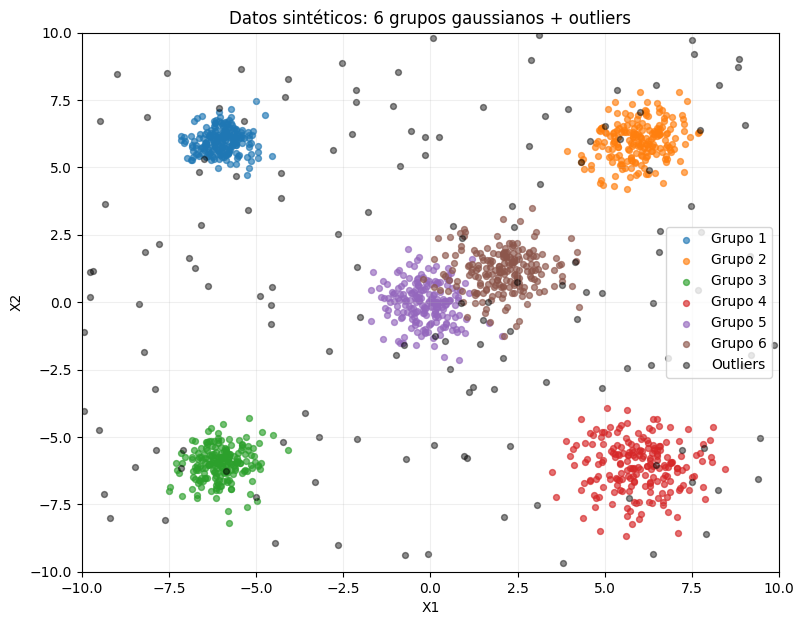

In [3]:
plt.figure(figsize=(9, 7))

for i in range(n_clusters_true):
    mask = y_all == i
    plt.scatter(X_all[mask, 0], X_all[mask, 1], s=18, alpha=0.65, label=f'Grupo {i+1}')

mask_out = y_all == -1
plt.scatter(X_all[mask_out, 0], X_all[mask_out, 1],
            s=18, c='black', alpha=0.45, label='Outliers')

plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Datos sintéticos: 6 grupos gaussianos + outliers')
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## 3. Remoción de outliers

Se utiliza **Local Outlier Factor (LOF)** para detectar observaciones con una densidad local considerablemente menor que la de sus vecinos. El proceso de detección no utiliza las etiquetas verdaderas.


In [4]:
contamination = n_outliers / len(X_all)

lof = LocalOutlierFactor(
    n_neighbors=25,
    contamination=contamination
)

inlier_mask = lof.fit_predict(X_all) == 1

X_clean = X_all[inlier_mask]
y_clean = y_all[inlier_mask]

print(f'Puntos antes de LOF: {len(X_all)}')
print(f'Puntos después de LOF: {len(X_clean)}')
print(f'Puntos removidos por LOF: {np.sum(~inlier_mask)}')
print(f'Outliers verdaderos que permanecen: {np.sum(y_clean == -1)}')


Puntos antes de LOF: 1350
Puntos después de LOF: 1200
Puntos removidos por LOF: 150
Outliers verdaderos que permanecen: 32


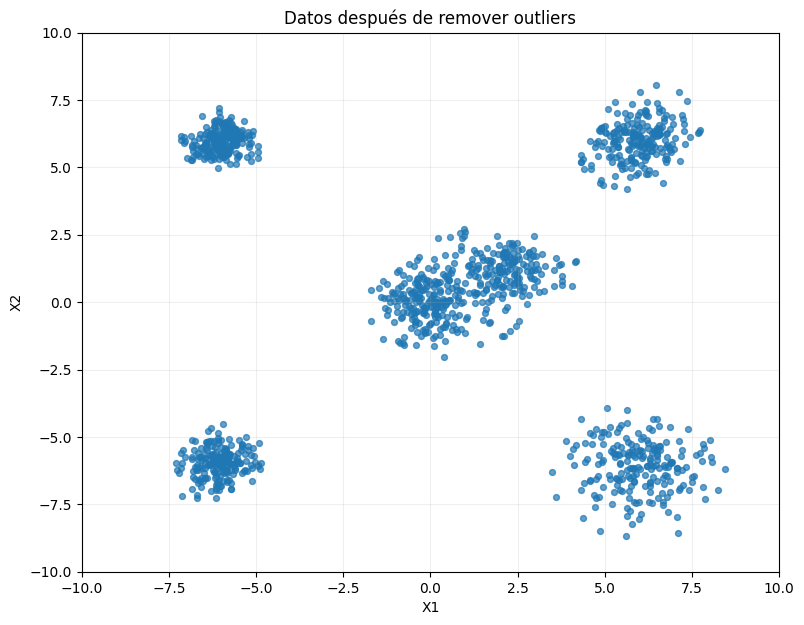

In [5]:
plt.figure(figsize=(9, 7))
plt.scatter(X_clean[:, 0], X_clean[:, 1], s=18, alpha=0.7)
plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Datos después de remover outliers')
plt.grid(alpha=0.2)
plt.show()


## 4. Exploración de K = 2 a K = 12

Se ajusta K-Means para cada valor de K entre 2 y 12. Se utiliza `n_init=20` para reducir la dependencia de una única inicialización. Se guardan la inercia, Silhouette, ARI y NMI.


In [6]:
K_range = range(2, 13)

models = {}
inertias = []
silhouettes = []
aris = []
nmis = []

# Los outliers residuales detectados por LOF no se consideran una séptima clase
# al calcular las métricas basadas en Ground Truth.
eval_mask = y_clean != -1
X_eval = X_clean[eval_mask]
y_eval = y_clean[eval_mask]

for k in K_range:
    model = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=RANDOM_STATE
    )
    labels = model.fit_predict(X_clean)

    models[k] = model
    inertias.append(model.inertia_)
    silhouettes.append(silhouette_score(X_clean, labels))

    labels_eval = labels[eval_mask]
    aris.append(adjusted_rand_score(y_eval, labels_eval))
    nmis.append(normalized_mutual_info_score(y_eval, labels_eval))

results = pd.DataFrame({
    'K': list(K_range),
    'Inercia': inertias,
    'Silhouette': silhouettes,
    'ARI': aris,
    'NMI': nmis,
})

results.round(4)


,K,Inercia,Silhouette,ARI,NMI
0,2,35751.3442,0.4559,0.2649,0.4937
1,3,22003.5319,0.5673,0.3246,0.6474
2,4,9313.5902,0.7003,0.5663,0.8175
3,5,1815.0152,0.8061,0.8224,0.9310
4,6,1171.9156,0.7354,0.9645,0.9671
5,7,1048.8773,0.6525,0.9090,0.9363
6,8,957.9394,0.6109,0.8492,0.9002
7,9,874.1392,0.5341,0.7865,0.8738
8,10,789.7679,0.5418,0.7636,0.8572
9,11,724.5706,0.5319,0.7317,0.8383


## 5. Método de Silhouette

El coeficiente Silhouette mide la cohesión de cada punto dentro de su cluster y su separación respecto a los clusters vecinos. Valores más altos indican una mejor partición.

Se selecciona el K que maximiza el promedio de Silhouette.


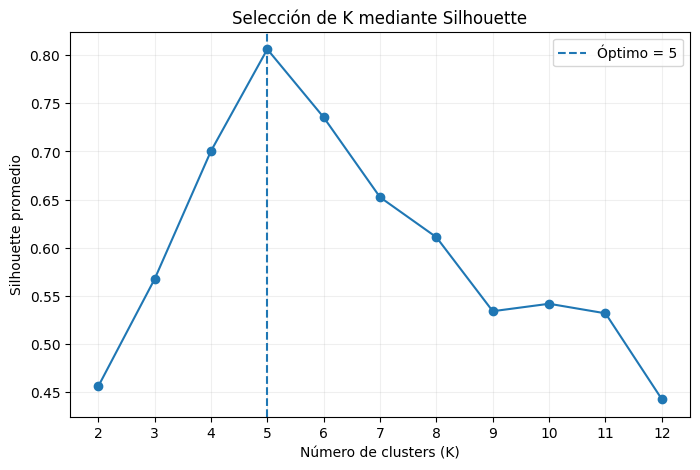

K óptimo según Silhouette: 5
Silhouette máximo: 0.8061


In [7]:
k_silhouette = list(K_range)[int(np.argmax(silhouettes))]
silhouette_max = max(silhouettes)

plt.figure(figsize=(8, 5))
plt.plot(list(K_range), silhouettes, marker='o')
plt.axvline(k_silhouette, linestyle='--', label=f'Óptimo = {k_silhouette}')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Silhouette promedio')
plt.title('Selección de K mediante Silhouette')
plt.xticks(list(K_range))
plt.grid(alpha=0.2)
plt.legend()
plt.show()

print(f'K óptimo según Silhouette: {k_silhouette}')
print(f'Silhouette máximo: {silhouette_max:.4f}')


## 6. Método del codo (Elbow)

La inercia disminuye al aumentar K. El codo se aproxima mediante la máxima distancia de los puntos de la curva a la línea que une el primer y el último valor.


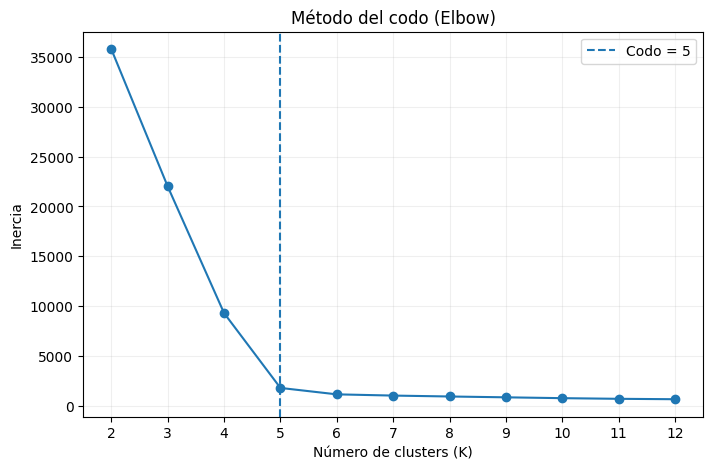

K óptimo según Elbow: 5


In [8]:
ks = np.array(list(K_range), dtype=float)
ys = np.array(inertias, dtype=float)

x1, y1 = ks[0], ys[0]
x2, y2 = ks[-1], ys[-1]

distances = (
    np.abs((y2-y1)*ks - (x2-x1)*ys + x2*y1 - y2*x1)
    / np.sqrt((y2-y1)**2 + (x2-x1)**2)
)

k_elbow = int(ks[np.argmax(distances)])

plt.figure(figsize=(8, 5))
plt.plot(ks, ys, marker='o')
plt.axvline(k_elbow, linestyle='--', label=f'Codo = {k_elbow}')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inercia')
plt.title('Método del codo (Elbow)')
plt.xticks(list(K_range))
plt.grid(alpha=0.2)
plt.legend()
plt.show()

print(f'K óptimo según Elbow: {k_elbow}')


## 7. Método basado en Ground Truth

Como los datos son sintéticos, conocemos las etiquetas verdaderas. Se utilizan **ARI (Adjusted Rand Index)** y **NMI (Normalized Mutual Information)** para comparar la partición de K-Means con esas etiquetas.

En ambas métricas, un valor cercano a 1 indica mayor correspondencia entre el agrupamiento obtenido y el Ground Truth.


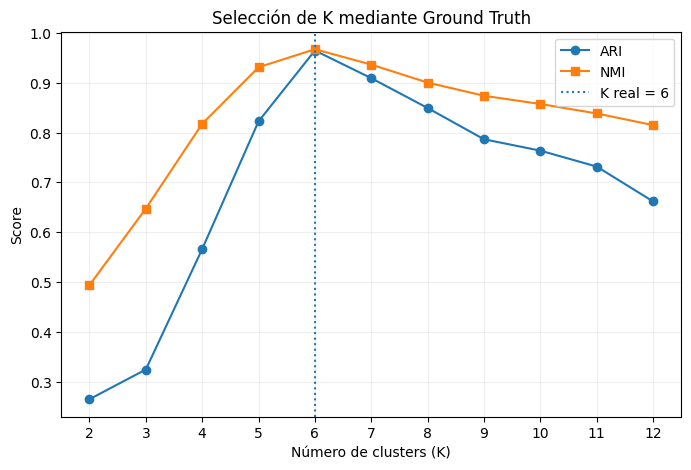

K óptimo según ARI: 6 (ARI = 0.9645)
K óptimo según NMI: 6 (NMI = 0.9671)


In [9]:
k_ari = list(K_range)[int(np.argmax(aris))]
k_nmi = list(K_range)[int(np.argmax(nmis))]

plt.figure(figsize=(8, 5))
plt.plot(list(K_range), aris, marker='o', label='ARI')
plt.plot(list(K_range), nmis, marker='s', label='NMI')
plt.axvline(n_clusters_true, linestyle=':', label='K real = 6')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Score')
plt.title('Selección de K mediante Ground Truth')
plt.xticks(list(K_range))
plt.grid(alpha=0.2)
plt.legend()
plt.show()

print(f'K óptimo según ARI: {k_ari} (ARI = {max(aris):.4f})')
print(f'K óptimo según NMI: {k_nmi} (NMI = {max(nmis):.4f})')


## 8. Comparación de los métodos

Se comparan los valores de K obtenidos por los tres criterios con el número real de grupos, que es 6.


In [10]:
comparison = pd.DataFrame({
    'Método': [
        'Elbow',
        'Silhouette',
        'Ground Truth - ARI',
        'Ground Truth - NMI',
        'Número real'
    ],
    'K óptimo': [
        k_elbow,
        k_silhouette,
        k_ari,
        k_nmi,
        n_clusters_true
    ]
})

comparison


,Método,K óptimo
0,Elbow,5
1,Silhouette,5
2,Ground Truth - ARI,6
3,Ground Truth - NMI,6
4,Número real,6


## 9. Clustering final con K = 6

El número real de grupos generados es 6. Se entrena un modelo final con K=6 sobre los datos después de la remoción de outliers y se evalúa mediante ARI y NMI contra las etiquetas verdaderas de los puntos pertenecientes a los seis grupos.


In [11]:
final_model = KMeans(
    n_clusters=6,
    n_init=20,
    random_state=RANDOM_STATE
)

final_labels = final_model.fit_predict(X_clean)
final_labels_eval = final_labels[eval_mask]

final_ari = adjusted_rand_score(y_eval, final_labels_eval)
final_nmi = normalized_mutual_info_score(y_eval, final_labels_eval)

print(f'ARI final para K=6: {final_ari:.4f}')
print(f'NMI final para K=6: {final_nmi:.4f}')
print(f'Puntos evaluados: {len(X_eval)}')


ARI final para K=6: 0.9645
NMI final para K=6: 0.9671
Puntos evaluados: 1168


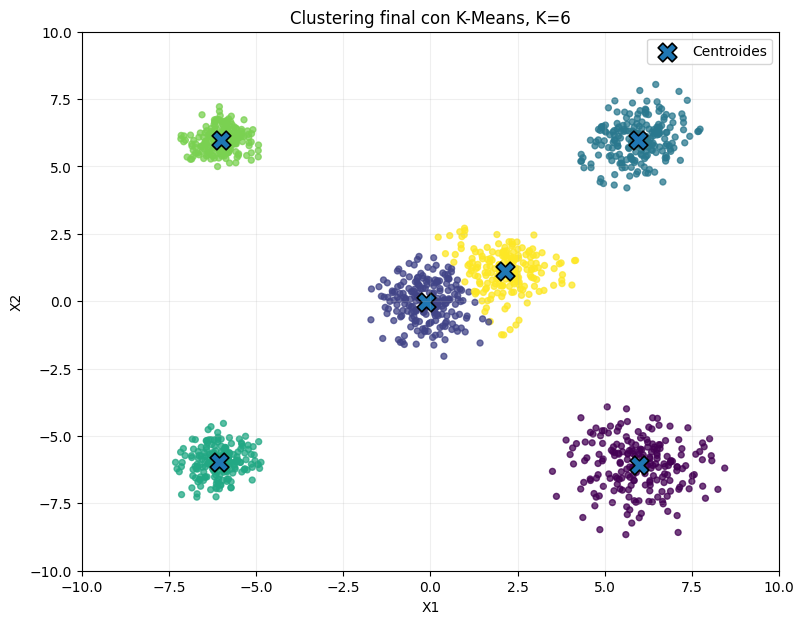

In [12]:
plt.figure(figsize=(9, 7))
plt.scatter(
    X_clean[:, 0],
    X_clean[:, 1],
    c=final_labels,
    s=18,
    alpha=0.75
)

plt.scatter(
    final_model.cluster_centers_[:, 0],
    final_model.cluster_centers_[:, 1],
    marker='X',
    s=180,
    edgecolor='black',
    linewidth=1.2,
    label='Centroides'
)

plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Clustering final con K-Means, K=6')
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## 10. Conclusiones

1. Se construyó un conjunto sintético bidimensional con **6 grupos gaussianos isotrópicos**, todos con el mismo número de puntos pero con diferentes desviaciones estándar.
2. Los grupos 5 y 6 fueron ubicados deliberadamente cerca para producir **superposición parcial**.
3. Se agregaron **150 outliers uniformes** dentro de `[-10,10] × [-10,10]` y se mantuvo el conjunto dentro del rango solicitado.
4. Se utilizó **Local Outlier Factor** para remover puntos atípicos antes de aplicar K-Means, sin utilizar las etiquetas verdaderas en la detección.
5. Se exploraron todos los valores de **K entre 2 y 12**.
6. Se aplicaron los métodos **Silhouette** y **Elbow** como criterios no supervisados.
7. Se aplicaron **ARI y NMI** como métodos de validación basados en Ground Truth.
8. Finalmente, se entrenó K-Means con **K=6**, correspondiente al número real de grupos generados.

Los resultados deben interpretarse considerando que dos grupos fueron diseñados para superponerse. Esta condición puede hacer que los criterios no supervisados prefieran una partición diferente de K=6, mientras que las métricas basadas en Ground Truth permiten comprobar qué valor de K reproduce mejor las etiquetas con las que se generaron los datos.

### Entrega

Completar los nombres de los integrantes, ejecutar todas las celdas, guardar el cuaderno con los resultados y subirlo al repositorio de GitHub compartido con el profesor. Finalmente, enviar el enlace del repositorio por Brightspace.
